In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
data=pd.read_csv("D:/dataset/unsupervised/Mall_Customers.csv")
data

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [38]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [39]:
data.isna().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [40]:
data.drop(['CustomerID'],axis=1,inplace=True)
data.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


In [41]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
data['Gender']=le.fit_transform(data['Gender'])
data['Gender']

0      1
1      1
2      0
3      0
4      0
      ..
195    0
196    0
197    1
198    1
199    1
Name: Gender, Length: 200, dtype: int64

In [42]:
from sklearn.preprocessing import MinMaxScaler
Scaler=MinMaxScaler()
data_scale=Scaler.fit_transform(data)
print(data.head())

   Gender  Age  Annual Income (k$)  Spending Score (1-100)
0       1   19                  15                      39
1       1   21                  15                      81
2       0   20                  16                       6
3       0   23                  16                      77
4       0   31                  17                      40


In [43]:
from sklearn.cluster import KMeans
wcss=[]
for i in range(1,11):
    k_means=KMeans(n_clusters=i,init="k-means++",max_iter=300,n_init=10,random_state=42)
    k_means.fit(data_scale)
    wcss.append( k_means.inertia_)
print(wcss)
    

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

[86.68148216035944, 37.27227241211876, 29.552857611943857, 22.390960011928552, 19.06284091969291, 16.413737030973795, 14.221778248633633, 12.243825066854683, 10.60043296955085, 9.668482302211679]


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


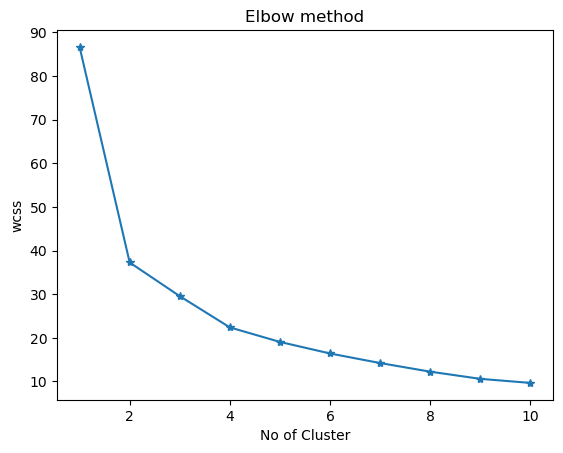

In [44]:
plt.plot(range(1,11),wcss,marker="*")
plt.title("Elbow method")
plt.xlabel("No of Cluster")
plt.ylabel("wcss")
plt.show()

In [45]:
k_means=KMeans(n_clusters=3,random_state=42)
cluster_label=k_means.fit_predict(data_scale)
cluster_label

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


array([0, 0, 1, 2, 2, 2, 1, 2, 0, 2, 0, 2, 1, 2, 0, 0, 1, 0, 0, 2, 0, 0,
       1, 0, 1, 0, 1, 0, 1, 2, 0, 2, 0, 0, 1, 2, 1, 2, 1, 2, 1, 0, 0, 2,
       1, 2, 1, 2, 2, 2, 1, 0, 2, 0, 1, 0, 1, 0, 2, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 0, 2, 0, 1, 1, 1, 0, 0, 1, 0, 2, 1, 0, 0, 0, 1, 2, 0, 1, 2,
       2, 1, 1, 0, 0, 1, 2, 0, 1, 2, 0, 0, 2, 1, 0, 0, 0, 2, 1, 0, 0, 0,
       0, 2, 1, 0, 2, 2, 1, 1, 1, 1, 0, 1, 2, 0, 2, 2, 0, 0, 0, 0, 0, 0,
       2, 2, 0, 2, 1, 0, 0, 2, 1, 0, 2, 2, 0, 0, 0, 2, 1, 0, 0, 0, 1, 2,
       1, 2, 0, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2, 1, 0, 0, 0, 0, 0, 1, 2,
       0, 0, 0, 0, 1, 2, 0, 2, 1, 0, 1, 0, 1, 2, 1, 2, 0, 2, 1, 2, 1, 0,
       0, 0], dtype=int32)

In [46]:
data["clusterID"]=cluster_label
data
data.head(50)


,Gender,Age,Annual Income (k$),Spending Score (1-100),clusterID
0,1,19,15,39,0
1,1,21,15,81,0
2,0,20,16,6,1
3,0,23,16,77,2
4,0,31,17,40,2
5,0,22,17,76,2
6,0,35,18,6,1
7,0,23,18,94,2
8,1,64,19,3,0
9,0,30,19,72,2


In [47]:
from sklearn.metrics import silhouette_score
print(silhouette_score(data_scale,cluster_label))

0.3966438735627507


In [48]:
print(data_scale)

[[1.         0.01923077 0.         0.3877551 ]
 [1.         0.05769231 0.         0.81632653]
 [0.         0.03846154 0.00819672 0.05102041]
 [0.         0.09615385 0.00819672 0.7755102 ]
 [0.         0.25       0.01639344 0.39795918]
 [0.         0.07692308 0.01639344 0.76530612]
 [0.         0.32692308 0.02459016 0.05102041]
 [0.         0.09615385 0.02459016 0.94897959]
 [1.         0.88461538 0.03278689 0.02040816]
 [0.         0.23076923 0.03278689 0.7244898 ]
 [1.         0.94230769 0.03278689 0.13265306]
 [0.         0.32692308 0.03278689 1.        ]
 [0.         0.76923077 0.04098361 0.14285714]
 [0.         0.11538462 0.04098361 0.7755102 ]
 [1.         0.36538462 0.04098361 0.12244898]
 [1.         0.07692308 0.04098361 0.79591837]
 [0.         0.32692308 0.04918033 0.34693878]
 [1.         0.03846154 0.04918033 0.66326531]
 [1.         0.65384615 0.06557377 0.28571429]
 [0.         0.32692308 0.06557377 0.98979592]
 [1.         0.32692308 0.07377049 0.34693878]
 [1.         

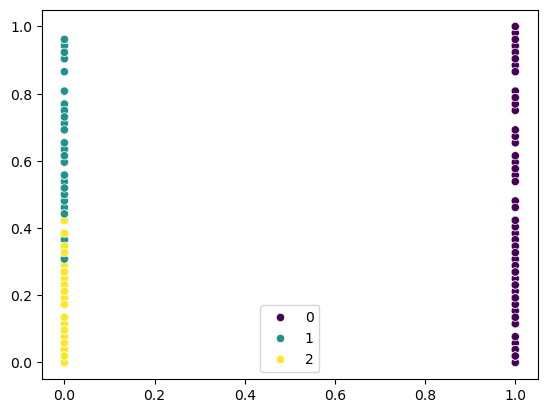

In [49]:
sns.scatterplot(x=data_scale[:,0],y=data_scale[:,1],hue=cluster_label,palette="viridis")
plt.show()

In [50]:
count_clust=data["clusterID"].value_counts()
count_clust

clusterID
0    88
2    57
1    55
Name: count, dtype: int64

In [51]:
 # data.groupby("clusterID", as_index=False).mean()
data.groupby("clusterID").mean()


,Gender,Age,Annual Income (k$),Spending Score (1-100)
clusterID,,,,
0,1.0,39.806818,62.227273,48.511364
1,0.0,48.109091,58.818182,34.781818
2,0.0,28.438596,59.666667,67.684211


In [52]:
new_data=[[1,29,62,69]]
Ndata_scaled=Scaler.transform(new_data)
k_means.predict(Ndata_scaled)


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


array([0], dtype=int32)